In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph

In [170]:
test_img = './images/39627812096707320_image.jpg'
img_array = plt.imread(test_img)[:, :, 0]


In [171]:
print(img_array.shape)

(200, 200)


In [172]:
# from PIL import Image

# # Open the image
# img = Image.open(test_img)

# # Convert to grayscale
# img_array = img.convert('L')
# img_array = np.array(img_array)

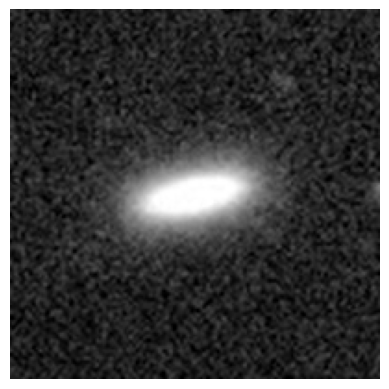

In [173]:

plt.imshow(img_array, cmap='gray', origin='lower')
plt.axis('off')
plt.show()

In [174]:
img_array = img_array - np.mean(img_array[0:10, 0:10])
img_array = np.clip(img_array, 0, np.max(img_array))
img_array = img_array / np.max(img_array)

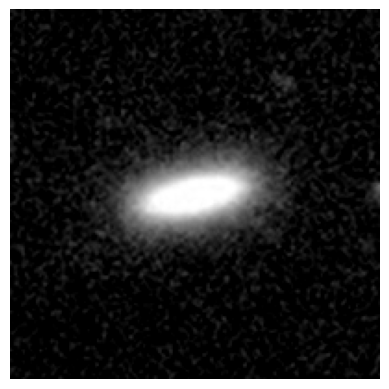

In [175]:

plt.imshow(img_array, cmap='gray', origin='lower')
plt.axis('off')
plt.show()

In [176]:
# norm = simple_norm(img_array, 'sinh', percent=99.0)
# plt.imshow(img_array, norm=norm, origin='lower', cmap='gray')
# plt.axis('off')
# plt.show()

In [177]:
# img_array = norm(img_array).data
# plt.imshow(img_array, cmap='gray', origin='lower')
# plt.axis('off')
# plt.show()

In [178]:
threshold = detect_threshold(img_array, 5)
npixels = 400  # minimum number of connected pixels
segmap = detect_sources(img_array, threshold, npixels)
segmap = np.array(segmap)
print(segmap.shape)


(200, 200)


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_49421/3014756172.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  segmap = np.array(segmap)


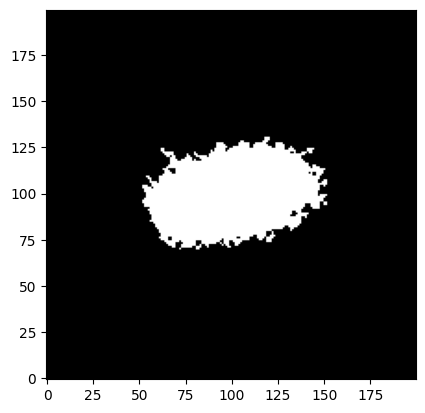

In [179]:

plt.imshow(segmap, cmap='gray', origin='lower')
plt.show()


In [180]:

segmap = np.where(segmap != segmap[int(segmap.shape[0]/2), int(segmap.shape[1]/2)], 0, 1)

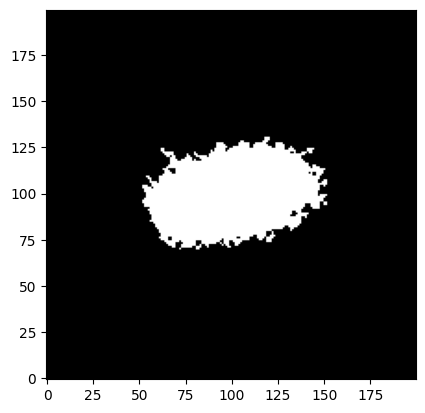

In [181]:

plt.imshow(segmap, cmap='gray', origin='lower')
plt.show()


In [182]:
start = time.time()
source_morphs = statmorph.source_morphology(img_array, segmap, gain=1e-1)
print('Time: %g s.' % (time.time() - start))

Time: 0.464483 s.


In [183]:
morph = source_morphs[0]

In [184]:
print('BASIC MEASUREMENTS (NON-PARAMETRIC)')
print('xc_centroid =', morph.xc_centroid)
print('yc_centroid =', morph.yc_centroid)
print('ellipticity_centroid =', morph.ellipticity_centroid)
print('elongation_centroid =', morph.elongation_centroid)
print('orientation_centroid =', morph.orientation_centroid)
print('xc_asymmetry =', morph.xc_asymmetry)
print('yc_asymmetry =', morph.yc_asymmetry)
print('ellipticity_asymmetry =', morph.ellipticity_asymmetry)
print('elongation_asymmetry =', morph.elongation_asymmetry)
print('orientation_asymmetry =', morph.orientation_asymmetry)
print('rpetro_circ =', morph.rpetro_circ)
print('rpetro_ellip =', morph.rpetro_ellip)
print('rhalf_circ =', morph.rhalf_circ)
print('rhalf_ellip =', morph.rhalf_ellip)
print('r20 =', morph.r20)
print('r80 =', morph.r80)
print('Gini =', morph.gini)
print('M20 =', morph.m20)
print('F(G, M20) =', morph.gini_m20_bulge)
print('S(G, M20) =', morph.gini_m20_merger)
print('sn_per_pixel =', morph.sn_per_pixel)
print('C =', morph.concentration)
print('A =', morph.asymmetry)
print('S =', morph.smoothness)
print()
print('SERSIC MODEL')
print('sersic_amplitude =', morph.sersic_amplitude)
print('sersic_rhalf =', morph.sersic_rhalf)
print('sersic_n =', morph.sersic_n)
print('sersic_xc =', morph.sersic_xc)
print('sersic_yc =', morph.sersic_yc)
print('sersic_ellip =', morph.sersic_ellip)
print('sersic_theta =', morph.sersic_theta)
print('sersic_chi2_dof =', morph.sersic_chi2_dof)
print()
print('OTHER')
print('sky_mean =', morph.sky_mean)
print('sky_median =', morph.sky_median)
print('sky_sigma =', morph.sky_sigma)
print('flag =', morph.flag)
print('flag_sersic =', morph.flag_sersic)

BASIC MEASUREMENTS (NON-PARAMETRIC)
xc_centroid = 99.49428299393809
yc_centroid = 99.04808741964342
ellipticity_centroid = 0.4882181593850987
elongation_centroid = 1.9539575667602997
orientation_centroid = 0.18933799680056784
xc_asymmetry = 98.33077155026947
yc_asymmetry = 98.73333333078654
ellipticity_asymmetry = 0.48901914430265914
elongation_asymmetry = 1.9570204810027367
orientation_asymmetry = 0.18966239513782734
rpetro_circ = 54.668146374967314
rpetro_ellip = 70.07355271619669
rhalf_circ = 30.180311616056745
rhalf_ellip = 38.87730308255078
r20 = 13.975980492841945
r80 = 46.79212307664475
Gini = 0.5068703783960132
M20 = -1.4332754211458085
F(G, M20) = -0.4577317600856894
S(G, M20) = -0.024423608927214346
sn_per_pixel = 0.15296716405882568
C = 2.6239523243609266
A = 0.13352229081136605
S = 0.06352997013479315

SERSIC MODEL
sersic_amplitude = 0.4914608661543267
sersic_rhalf = 30.089075000890112
sersic_n = 0.67581673872286
sersic_xc = 99.05798733610635
sersic_yc = 99.0168149653156
se

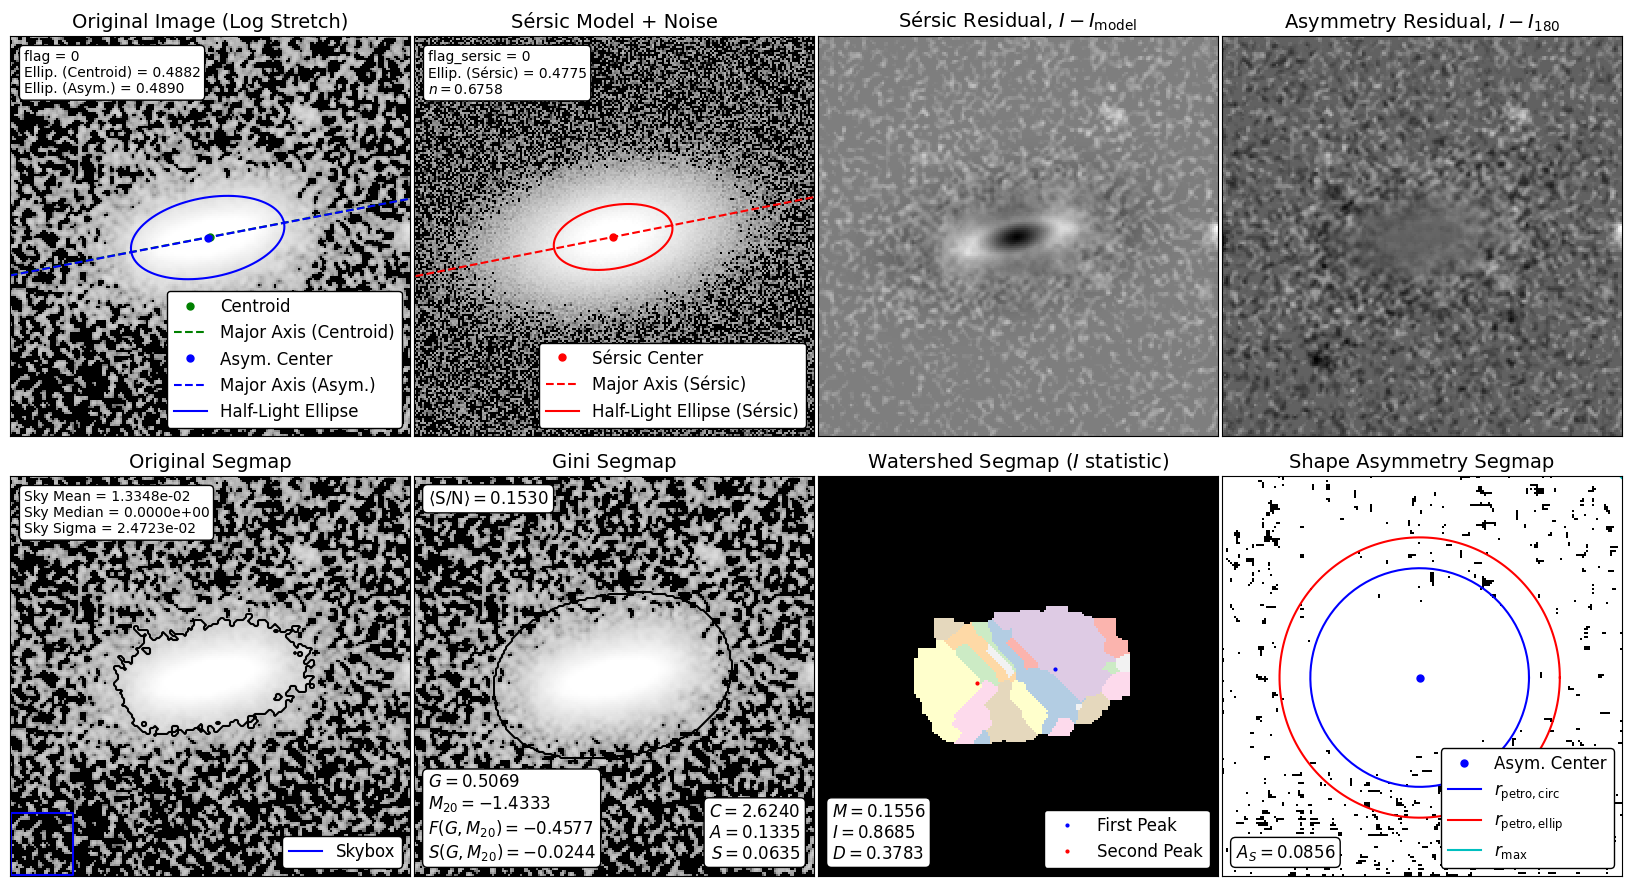

In [185]:
from statmorph.utils.image_diagnostics import make_figure
fig = make_figure(morph)